# Hillstrom Email Marketing - Data Understanding & Quality Assessment

## Dataset Overview

The Hillstrom Email Marketing Dataset comes from an email marketing experiment conducted by Kevin Hillstrom.

The dataset contains **64,000 customers** and **12 columns**. Each row represents one customer who had purchase activity during the 12 months before the experiment.

Customers were randomly assigned to one of three groups:

- `Mens E-Mail`: received an email promoting men's merchandise;
- `Womens E-Mail`: received an email promoting women's merchandise;
- `No E-Mail`: received no email and served as the control group.

Customer behavior was observed for two weeks after the campaign.

### Dataset Variables

The 12 columns can be grouped into customer characteristics, treatment assignment, and post-campaign outcomes.

| Column | Description |
|---|---|
| `recency` | Number of months since the customer's last purchase | Customer characteristic |
| `history_segment` | Category representing the customer's historical spending level |
| `history` | Total amount spent by the customer during the previous 12 months |
| `mens` | Whether the customer had previously purchased men's merchandise |
| `womens` | Whether the customer had previously purchased women's merchandise |
| `zip_code` | Customer's geographic area: Rural, Surburban, or Urban |
| `newbie` | Whether the customer is a new customer |
| `channel` | Customer's historical purchasing channel: Web, Phone, or Multichannel |
| `segment` | Email campaign assigned to the customer |
| `visit` | Whether the customer visited the website during the post-campaign period |
| `conversion` | Whether the customer made a purchase during the post-campaign period |
| `spend` | Amount spent by the customer during the post-campaign period |

The customer characteristics describe information available before the email campaign, while `segment` represents the campaign assignment and `visit`, `conversion`, and `spend` represent post-campaign behavior.



In [123]:
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


COLORS = {
    "pacific_green": "#017360",
    "rainy_lake": "#446E8F",
    "serene_sea": "#77A7C4",
    "sora_blue": "#A1DBF1",
    "afterglow": "#F2E6CE",
    "bungalow_maple": "#F3D094",
}

PALETTE = list(COLORS.values())


plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [124]:
PROJECT_ROOT = Path.cwd().parents[1]

RAW_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "hillstrom"
    / "Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
)

if not RAW_PATH.exists():
    raise FileNotFoundError(
        "Hillstrom raw dataset was not found at:\n"
        f"{RAW_PATH}"
    )

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Raw dataset:",
    RAW_PATH,
)

Project root: d:\thao\d\uplif_model\uplif_customer_selection
Raw dataset: d:\thao\d\uplif_model\uplif_customer_selection\data\raw\hillstrom\Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv


In [125]:
raw_df = pd.read_csv(RAW_PATH)
df = raw_df.copy()
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Rows: 64,000
Columns: 12


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


#### Experimental assignment

| Column | Description | Role |
|---|---|---|
| `segment` | Assigned email campaign | Treatment assignment |

Expected treatment arms:

- `Mens E-Mail`
- `Womens E-Mail`
- `No E-Mail`

#### Post-treatment outcomes

| Column | Description | Role |
|---|---|---|
| `visit` | Website visit after campaign | Post-treatment outcome |
| `conversion` | Purchase after campaign | Post-treatment outcome |
| `spend` | Dollar amount spent after campaign | Post-treatment outcome |

The temporal distinction between pre-treatment variables and post-treatment outcomes will later be used to prevent leakage when defining the modeling feature set.

In [126]:
schema_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[col].dtype) for col in df.columns],
    "non_null": [df[col].notna().sum() for col in df.columns],
    "null": [df[col].isna().sum() for col in df.columns],
    "unique": [df[col].nunique(dropna=True) for col in df.columns],
})

schema_profile["null_pct"] = (schema_profile["null"]/len(df)*100)
display(schema_profile)


,column,dtype,non_null,null,unique,null_pct
0,recency,int64,64000,0,12,0.0000
1,history_segment,object,64000,0,7,0.0000
2,history,float64,64000,0,34833,0.0000
3,mens,int64,64000,0,2,0.0000
4,womens,int64,64000,0,2,0.0000
5,zip_code,object,64000,0,3,0.0000
6,newbie,int64,64000,0,2,0.0000
7,channel,object,64000,0,3,0.0000
8,segment,object,64000,0,3,0.0000
9,visit,int64,64000,0,2,0.0000


In [127]:
column_samples = []

for column in df.columns:
    values = (df[column].dropna().unique())

    sample_values = values[:8]

    column_samples.append({
        "column": column,
        "dtype": str(df[column].dtype),
        "n_unique": df[column].nunique(dropna=True),
        "sample_values": sample_values,
    })

column_samples = pd.DataFrame(column_samples)

display(column_samples)

,column,dtype,n_unique,sample_values
0,recency,int64,12,"[10, 6, 7, 9, 2, 1, 5, 4]"
1,history_segment,object,7,"[2) $100 - $200, 3) $200 - $350, 5) $500 - $75..."
2,history,float64,34833,"[142.44, 329.08, 180.65, 675.83, 45.34, 134.83..."
3,mens,int64,2,"[1, 0]"
4,womens,int64,2,"[0, 1]"
5,zip_code,object,3,"[Surburban, Rural, Urban]"
6,newbie,int64,2,"[0, 1]"
7,channel,object,3,"[Phone, Web, Multichannel]"
8,segment,object,3,"[Womens E-Mail, No E-Mail, Mens E-Mail]"
9,visit,int64,2,"[0, 1]"


In [128]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    display(duplicate_rows)
else:
    print("No exact duplicate rows found.")

Duplicate rows: 6,562


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
16,5,1) $0 - $100,29.9900,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0000
20,9,1) $0 - $100,29.9900,0,1,Surburban,1,Phone,No E-Mail,0,0,0.0000
23,2,1) $0 - $100,29.9900,0,1,Urban,1,Phone,No E-Mail,0,0,0.0000
33,9,1) $0 - $100,29.9900,1,0,Surburban,1,Phone,Mens E-Mail,0,0,0.0000
34,3,1) $0 - $100,29.9900,1,0,Rural,0,Web,Womens E-Mail,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
63942,3,1) $0 - $100,29.9900,1,0,Urban,1,Phone,No E-Mail,0,0,0.0000
63952,10,1) $0 - $100,29.9900,1,0,Rural,1,Web,No E-Mail,0,0,0.0000
63955,1,1) $0 - $100,29.9900,1,0,Surburban,0,Phone,Mens E-Mail,0,0,0.0000
63982,5,1) $0 - $100,29.9900,1,0,Urban,1,Phone,Mens E-Mail,0,0,0.0000


### Duplicate Records

The dataset contains **6,562 exact duplicate rows**.

However, the raw Hillstrom dataset does not provide a unique customer identifier. Therefore, identical rows cannot be reliably classified as duplicated customer records because different customers may share the same observed characteristics, treatment assignment, and outcomes.

For this reason, no rows are removed at this stage. All 64,000 observations are preserved for subsequent analysis.

In [129]:
numeric_columns = [
    "recency",
    "history",
    "spend",
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
recency,"64,000.0000",5.7637,3.5076,1.0000,2.0000,6.0000,9.0000,12.0000
history,"64,000.0000",242.0857,256.1586,29.9900,64.6600,158.1100,325.6575,"3,345.9300"
spend,"64,000.0000",1.0509,15.0364,0.0000,0.0000,0.0000,0.0000,499.0000


In [130]:
history_labels = [
    "1) $0 - $100",
    "2) $100 - $200",
    "3) $200 - $350",
    "4) $350 - $500",
    "5) $500 - $750",
    "6) $750 - $1,000",
    "7) $1,000 +",
]

expected_segment = pd.cut(
    df["history"],
    bins=[
        0,
        100,
        200,
        350,
        500,
        750,
        1000,
        np.inf,
    ],
    labels=history_labels,
    right=False,
)

segment_mismatch = (df["history_segment"]!= expected_segment.astype(str))

print("History segment mismatches:", f"{segment_mismatch.sum():,}",
)

if segment_mismatch.any():
    display(df.loc[segment_mismatch,["history","history_segment",],].head(20))

History segment mismatches: 0


In [131]:
binary_columns = [
    "visit",
    "conversion",
    "mens",
    "womens",
    "newbie"
]

display(df[binary_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
visit,"64,000.0000",0.1468,0.3539,0.0000,0.0000,0.0000,0.0000,1.0000
conversion,"64,000.0000",0.0090,0.0946,0.0000,0.0000,0.0000,0.0000,1.0000
mens,"64,000.0000",0.5510,0.4974,0.0000,0.0000,1.0000,1.0000,1.0000
womens,"64,000.0000",0.5497,0.4975,0.0000,0.0000,1.0000,1.0000,1.0000
newbie,"64,000.0000",0.5022,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000


### Data Quality Findings

The raw Hillstrom dataset is structurally complete and does not show major data-quality problems.

- The dataset contains **64,000 observations and 12 variables**, consistent with the documented dataset structure.
- No missing values were found.
- Binary variables (`mens`, `womens`, `newbie`, `visit`, and `conversion`) contain valid `0/1` values.
- `recency` ranges from **1 to 12 months**, which is consistent with the twelve-month customer history window.
- `history` is strictly positive, ranging from **29.99 to 3,345.93**.
- `spend` is non-negative, ranging from **0 to 499**.
- `history_segment` is internally consistent with the numeric `history` variable, with **0 segment mismatches**.
- **6,562 rows are exact repetitions of an earlier observed row.** Because the dataset does not contain a unique customer identifier, these rows cannot be confirmed as duplicated customer records and are therefore retained.


In [132]:
categorical_columns = [
    "history_segment",
    "zip_code",
    "channel",
    "segment",
]

for column in categorical_columns:
    df[column] = df[column].str.strip()

In [133]:
df["history_segment"] = (
    df["history_segment"]
    .str.replace(r"^\d+\)\s*", "", regex=True)
    .str.replace(" +", "+", regex=False)
)

In [134]:
df["zip_code"] = df["zip_code"].replace(
    "Surburban",
    "Suburban",
)

In [135]:
print("history_segment:")
print(df["history_segment"].value_counts().sort_index())

print("\nzip_code:")
print(df["zip_code"].value_counts())

history_segment:
history_segment
$0 - $100        22970
$1,000+           1308
$100 - $200      14254
$200 - $350      12289
$350 - $500       6409
$500 - $750       4911
$750 - $1,000     1859
Name: count, dtype: int64

zip_code:
zip_code
Suburban    28776
Urban       25661
Rural        9563
Name: count, dtype: int64


In [136]:
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,$100 - $200,142.4400,1,0,Suburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,$200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,$100 - $200,180.6500,0,1,Suburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,$500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,$0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


### Cleaning Result

Categorical formatting was standardized without changing the analytical content of the dataset.

- The ordinal prefixes in `history_segment` were removed while preserving the original spending intervals.
- `Surburban` was standardized to `Suburban`.
- Leading and trailing whitespace was removed from categorical fields.
- No observations were removed.
- No missing values were imputed.
- No numerical values were transformed.

The cleaned dataset still contains **64,000 observations** and is now ready for experimental-design and causal-assumption analysis.

## Experimental Design & Causal Assumptions

Hillstrom is described as a randomized marketing experiment with three campaign arms:

- `Mens E-Mail`
- `Womens E-Mail`
- `No E-Mail`

Before estimating treatment effects or training uplift models, the experimental structure should be checked empirically. These checks are intended as **design and data-quality diagnostics** for the causal analysis, rather than as formal proof of all causal assumptions.

The analysis focuses on five aspects:

1. **Treatment allocation** — whether the three campaign groups are approximately equally sized as expected under the randomized design.
2. **Sample ratio** — whether any observed difference in group sizes is larger than would be expected from random variation.
3. **Covariate balance** — whether observed pre-treatment customer characteristics are reasonably similar across treatment and control groups.
4. **Positivity and overlap** — whether the main customer subgroups contain observations across the experimental arms, so that treatment and control outcomes can be compared.
5. **Temporal ordering and leakage** — whether candidate predictors are measured before treatment and whether post-treatment information is excluded from the feature set.

These checks are used to verify that the observed data are consistent with the documented randomized experimental design and are suitable for subsequent treatment-effect and uplift analysis.

They do not prove the causal assumptions by themselves. Instead, they provide empirical evidence that there are no obvious issues with treatment allocation, pre-treatment balance, overlap, temporal ordering, or leakage in the available data.

In [137]:
segment_summary = (df["segment"].value_counts().rename("customers").to_frame())

segment_summary["percentage"] = (segment_summary["customers"]/len(df)*100)

display(segment_summary)


,customers,percentage
segment,,
Womens E-Mail,21387,33.4172
Mens E-Mail,21307,33.2922
No E-Mail,21306,33.2906


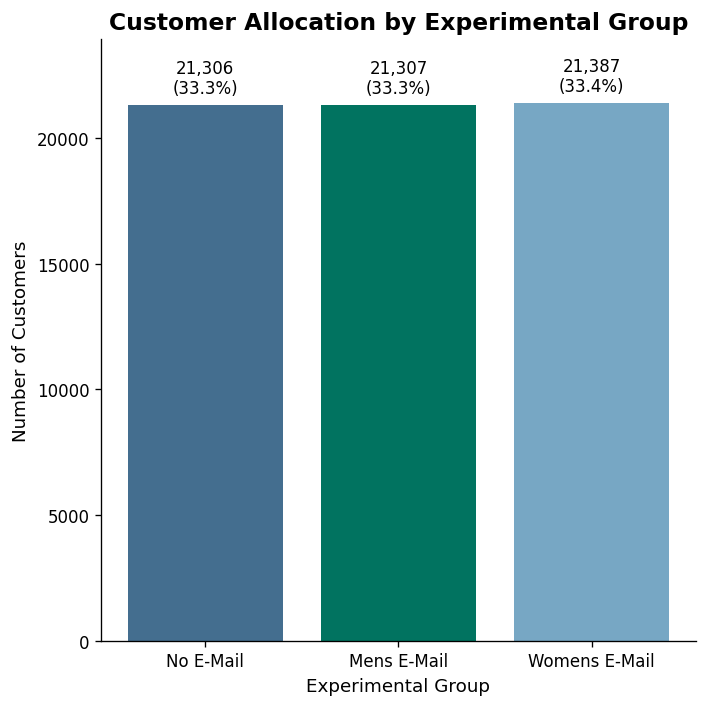

In [138]:
segment_order = [
    "No E-Mail",
    "Mens E-Mail",
    "Womens E-Mail"
]

segment_colors = [
    COLORS["rainy_lake"],
    COLORS["pacific_green"],
    COLORS["serene_sea"],
]

counts = (df["segment"].value_counts().reindex(segment_order))

fig, ax = plt.subplots(figsize=(6, 6))

bars = ax.bar(
    counts.index,
    counts.values,
    color=segment_colors,
)

ax.set_title("Customer Allocation by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Number of Customers")

for bar, value in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + counts.max() * 0.015,
        f"{value:,}\n({value / len(df):.1%})",
        ha="center",
        va="bottom",
    )

ax.set_ylim(0, counts.max() * 1.12)

plt.tight_layout()
plt.show()


In [139]:
from scipy.stats import chisquare

observed = segment_summary["customers"].values
expected = np.repeat(len(df)/3,3)

chi2, p_value = chisquare(observed, f_exp=expected,)

print(f"Chi-Square statistics {chi2:.3f}")
print(f"P-value: {p_value:.3f}")


Chi-Square statistics 0.203
P-value: 0.904


In [140]:
balance_df = pd.get_dummies(
    df[
        [
            "segment",
            "recency",
            "history",
            "mens",
            "womens",
            "newbie",
            "zip_code",
            "channel",
        ]
    ],
    columns=["zip_code","channel",],
    dtype=int,
)

def calculate_smd(data, feature, treatment_group):
    treatment = data.loc[data["segment"] == treatment_group,feature,]
    control = data.loc[data["segment"] == "No E-Mail",feature,]
    pooled_std = np.sqrt((treatment.var() + control.var())/2)

    return (treatment.mean() - control.mean()) / pooled_std

In [141]:
balance_features = [
    column
    for column in balance_df.columns
    if column != "segment"
]

balance_results = []

for treatment_group in ["Mens E-Mail","Womens E-Mail",]:
    for feature in balance_features:
        smd = calculate_smd(
            balance_df,
            feature,
            treatment_group,
        )

        balance_results.append({
            "comparison":
                f"{treatment_group} vs No E-Mail",
            "feature": feature,
            "smd": smd,
            "abs_smd": abs(smd),
        })

balance_results = pd.DataFrame(balance_results)

In [142]:
balance_table = (balance_results.pivot(index="feature",columns="comparison",values="smd",))

display(balance_table.round(3))

comparison,Mens E-Mail vs No E-Mail,Womens E-Mail vs No E-Mail
feature,,
channel_Multichannel,-0.0040,-0.0050
channel_Phone,-0.0080,0.0090
channel_Web,0.0110,-0.0050
history,0.0080,0.0070
mens,-0.0050,-0.0090
newbie,-0.0010,0.0030
recency,0.0070,0.0050
womens,0.0080,0.0050
zip_code_Rural,0.0140,0.0040


In [143]:
max_balance = (balance_results.sort_values("abs_smd",ascending=False,).iloc[0])

print("Maximum absolute SMD:",f"{max_balance['abs_smd']:.3f}",)

print("Feature:",max_balance["feature"],)

print("Comparison:",max_balance["comparison"],)

Maximum absolute SMD: 0.014
Feature: zip_code_Rural
Comparison: Mens E-Mail vs No E-Mail


In [144]:
overlap_columns = [
    "recency",
    "history_segment",
    "mens",
    "womens",
    "newbie",
    "zip_code",
    "channel",
]

overlap_results = []

for column in overlap_columns:
    table = pd.crosstab(df[column],df["segment"],)

    overlap_results.append({
        "feature": column,
        "zero_cells": (table == 0).sum().sum(),
        "minimum_group_size": table.min().min(),
    })

overlap_results = pd.DataFrame(overlap_results)

display(overlap_results)

,feature,zero_cells,minimum_group_size
0,recency,0,767
1,history_segment,0,416
2,mens,0,9519
3,womens,0,9558
4,newbie,0,10611
5,zip_code,0,3139
6,channel,0,2577


The observed data is consistent with the documented randomized experiment.

- The three experimental groups are almost equally sized, with approximately one-third of customers in each arm.
- The sample-ratio check shows no unexpected allocation imbalance (`χ² = 0.203`, `p = 0.904`).
- Pre-treatment characteristics are well balanced across treatment and control groups. The largest absolute standardized mean difference is only **0.014**, well below the commonly used 0.10 diagnostic threshold.
- All major customer subgroups contain observations from every experimental arm, with no empty treatment cells observed.

The available evidence therefore supports using the Hillstrom data for causal treatment-effect analysis. The dataset also provides clear temporal ordering: customer characteristics are observed before the campaign, while `visit`, `conversion`, and `spend` are post-campaign outcomes.

For later modeling, treatment assignment and post-treatment outcomes will remain separate from the feature set to avoid leakage.

## Exploratory Data Analysis

### Who are the customers in the dataset?


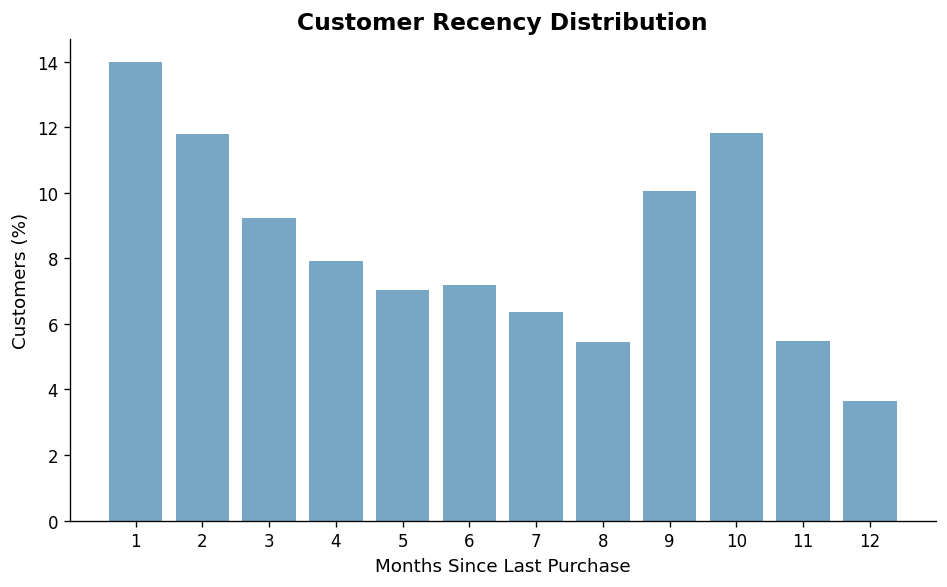

In [145]:
recency_pct = (df["recency"].value_counts(normalize=True).sort_index()*100)

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(recency_pct.index, recency_pct.values, color=COLORS["serene_sea"])
ax.set_title("Customer Recency Distribution")
ax.set_xlabel("Months Since Last Purchase")
ax.set_ylabel("Customers (%)")
ax.set_xticks(recency_pct.index)
plt.tight_layout()
plt.show()

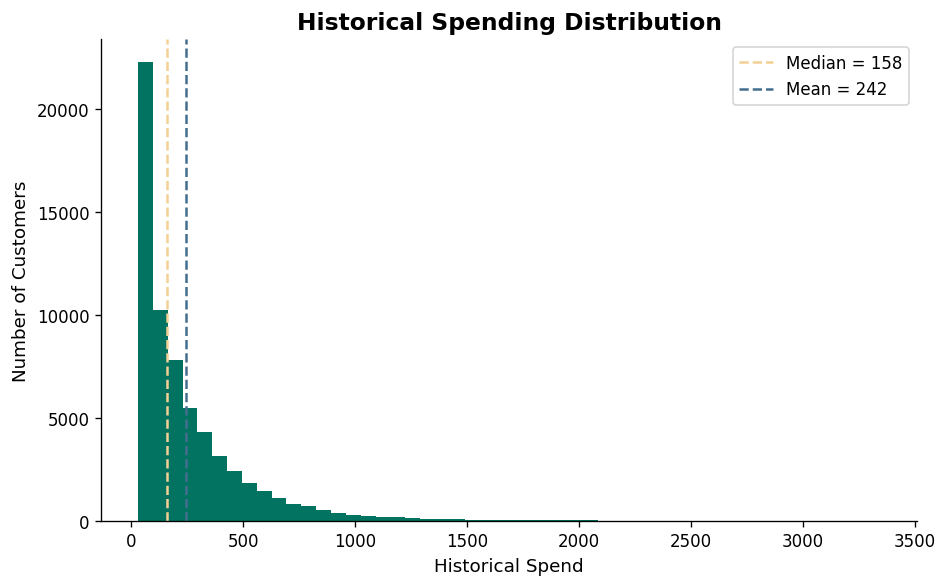

In [146]:
fig, ax = plt.subplots(figsize=(8,5))

ax.hist(df["history"], bins=50, color=COLORS["pacific_green"],)
ax.axvline(
    df["history"].median(), 
    color=COLORS["bungalow_maple"], 
    linestyle="--", 
    label=f"Median = {df["history"].median():.0f}",
)
ax.axvline(
    df["history"].mean(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    label=f"Mean = {df['history'].mean():.0f}",
)

ax.set_title("Historical Spending Distribution")
ax.set_xlabel("Historical Spend")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()


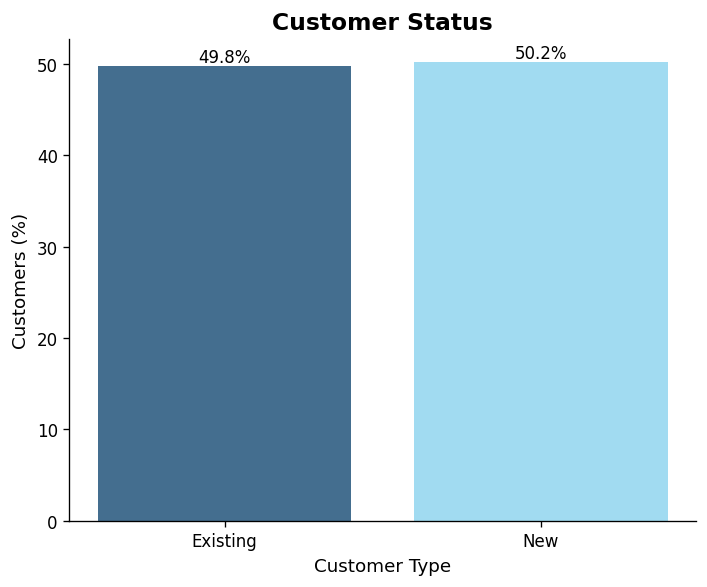

In [147]:
newbie_pct = (df["newbie"].value_counts(normalize=True).sort_index()*100)

newbie_pct.index = ["Existing", "New"]

fig, ax = plt.subplots(figsize=(6,5))
bars = ax.bar(
    newbie_pct.index,
    newbie_pct.values,
    color=[
        COLORS["rainy_lake"],
        COLORS["sora_blue"],
    ],

)
ax.set_title("Customer Status")
ax.set_xlabel("Customer Type")
ax.set_ylabel("Customers (%)")

for bar, value in zip(bars,newbie_pct.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

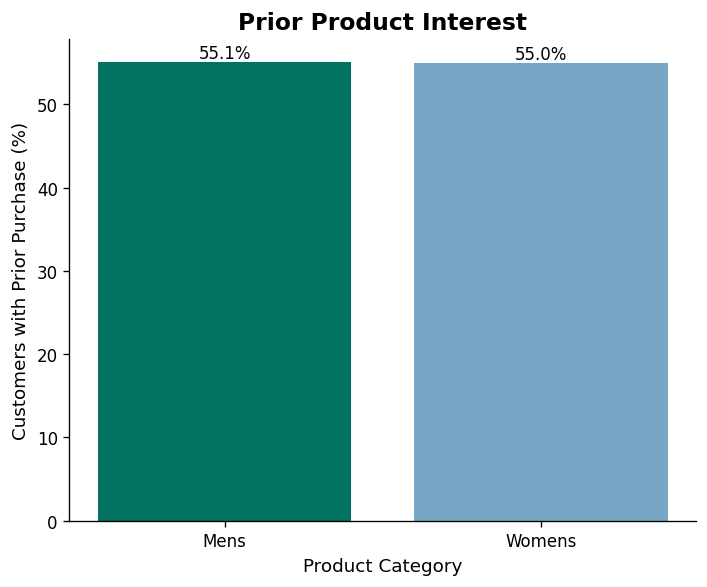

In [148]:
product_affinity = pd.Series({
    "Mens": df["mens"].mean() * 100,
    "Womens": df["womens"].mean() * 100,
})

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    product_affinity.index,
    product_affinity.values,
    color=[
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Prior Product Interest")
ax.set_xlabel("Product Category")
ax.set_ylabel("Customers with Prior Purchase (%)")

for bar, value in zip(bars,product_affinity.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

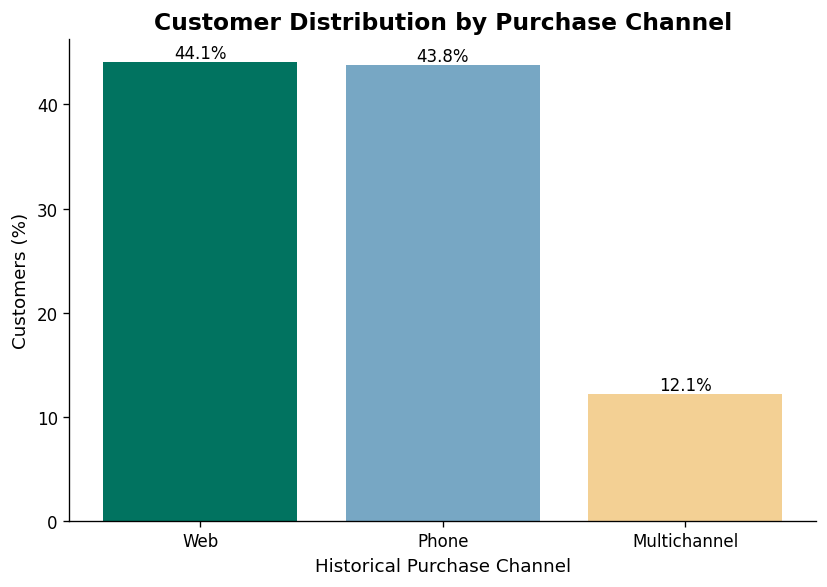

In [149]:
channel_pct = (df["channel"].value_counts(normalize=True)* 100)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    channel_pct.index,
    channel_pct.values,
    color=[
        COLORS["pacific_green"],
        COLORS["serene_sea"],
        COLORS["bungalow_maple"],
    ],
)

ax.set_title("Customer Distribution by Purchase Channel")
ax.set_xlabel("Historical Purchase Channel")
ax.set_ylabel("Customers (%)")

for bar, value in zip(bars,channel_pct.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

### Customer Population Findings

The Hillstrom customer population is fairly diverse rather than being dominated by one obvious customer type.

- **Recency:** Purchase recency is spread across the full 1–12 month range. Customers with a purchase one month ago form the largest group (about 14%), while months 9–10 also contain relatively large customer groups. 
- **Historical spending:** Historical spend is strongly right-skewed. The median is about **158**, while the mean is higher at about **242**, indicating that a smaller group of high-value customers pulls the average upward.
- **Customer status:** New and existing customers are almost evenly represented (**50.2% new vs 49.8% existing**).
- **Product affinity:** About **55%** of customers have previously purchased Mens merchandise and about **55%** have previously purchased Womens merchandise. These categories are not mutually exclusive, so a customer may have prior interest in both.
- **Purchase channel:** Web (**44.1%**) and Phone (**43.8%**) are the dominant historical purchase channels, while Multichannel customers represent a smaller share (**12.1%**).

Overall, the dataset contains meaningful variation in recency, historical value, customer tenure, product affinity, and purchasing channel, which may later help explain heterogeneous responses to the email campaigns.

### What are the behavioral outcomes following the campaign?


In [150]:
outcome_summary = pd.Series({
    "Visit rate (%)":
        df["visit"].mean() * 100,

    "Conversion rate (%)":
        df["conversion"].mean() * 100,

    "Customers with positive spend (%)":
        (df["spend"] > 0).mean() * 100,

    "Average spend":
        df["spend"].mean(),
})

display(outcome_summary.to_frame("value"))

,value
Visit rate (%),14.6781
Conversion rate (%),0.9031
Customers with positive spend (%),0.9031
Average spend,1.0509


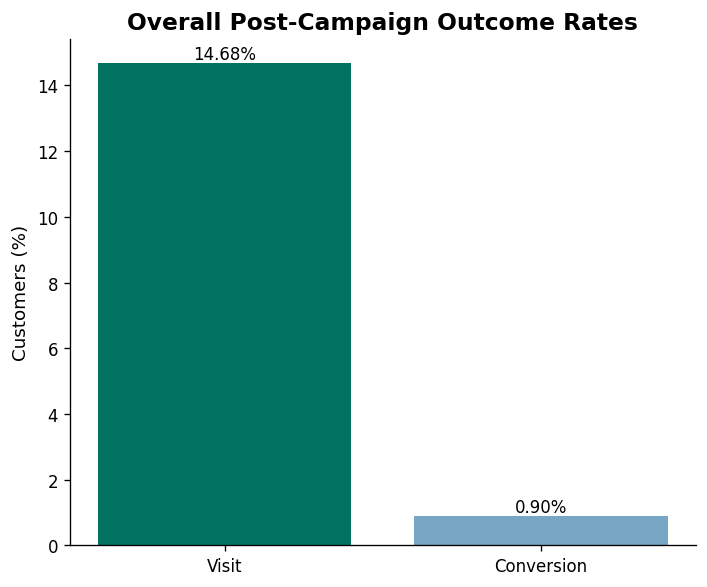

In [151]:
outcome_rates = pd.Series({
    "Visit":
        df["visit"].mean() * 100,

    "Conversion":
        df["conversion"].mean() * 100,
})

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(
    outcome_rates.index,
    outcome_rates.values,
    color=[
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Overall Post-Campaign Outcome Rates")
ax.set_ylabel("Customers (%)")

for bar, value in zip(bars,outcome_rates.values,):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

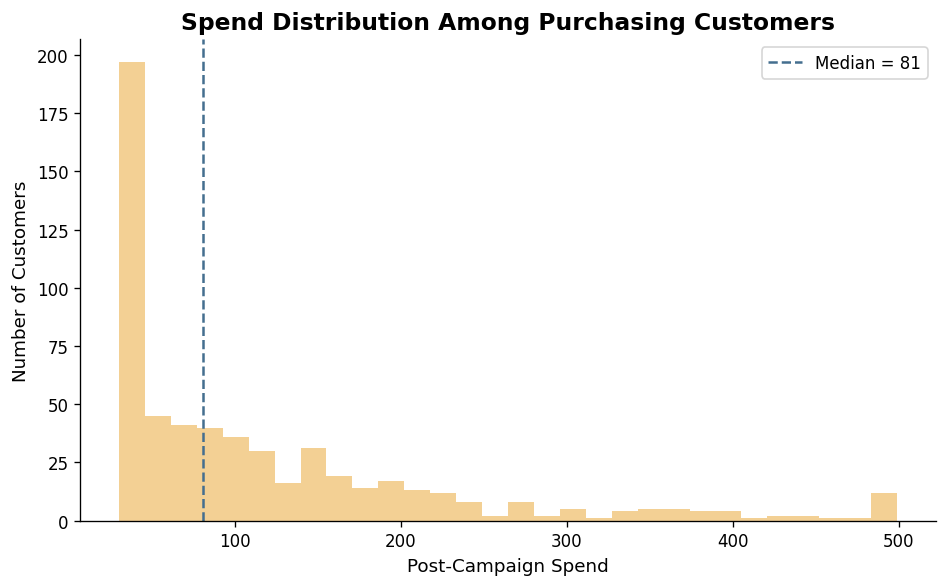

In [152]:
positive_spend = df.loc[df["spend"] > 0,"spend",]

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(positive_spend,bins=30,color=COLORS["bungalow_maple"],)

ax.axvline(
    positive_spend.median(),
    color=COLORS["rainy_lake"],
    linestyle="--",
    label=f"Median = {positive_spend.median():.0f}",
)

ax.set_title("Spend Distribution Among Purchasing Customers")
ax.set_xlabel("Post-Campaign Spend")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.show()

### Post-Campaign Outcome Behavior

Customer response after the campaign is relatively sparse, especially at the purchase stage.

- **14.68%** of customers visited after the campaign.
- Only **0.90%** converted.
- The proportion of customers with positive spend is also **0.90%**, consistent with the recorded conversion outcome.
- Average spend across the full population is only **1.05** because most customers made no purchase.
- Among customers who did purchase, spend is right-skewed with a median of approximately **81**, while a smaller number of customers spent substantially more.


### Do the outcomes differ between the treatments?


In [153]:
treatment_outcomes = (
    df.groupby("segment")
    .agg(
        customers=("segment", "size"),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean"),
        average_spend=("spend", "mean"),
    )
    .reindex([
        "No E-Mail",
        "Mens E-Mail",
        "Womens E-Mail",
    ])
)

treatment_outcomes["visit_rate"] *= 100

treatment_outcomes["conversion_rate"] *= 100

display(treatment_outcomes.round(3))

,customers,visit_rate,conversion_rate,average_spend
segment,,,,
No E-Mail,21306,10.6170,0.5730,0.6530
Mens E-Mail,21307,18.2760,1.2530,1.4230
Womens E-Mail,21387,15.1400,0.8840,1.0770


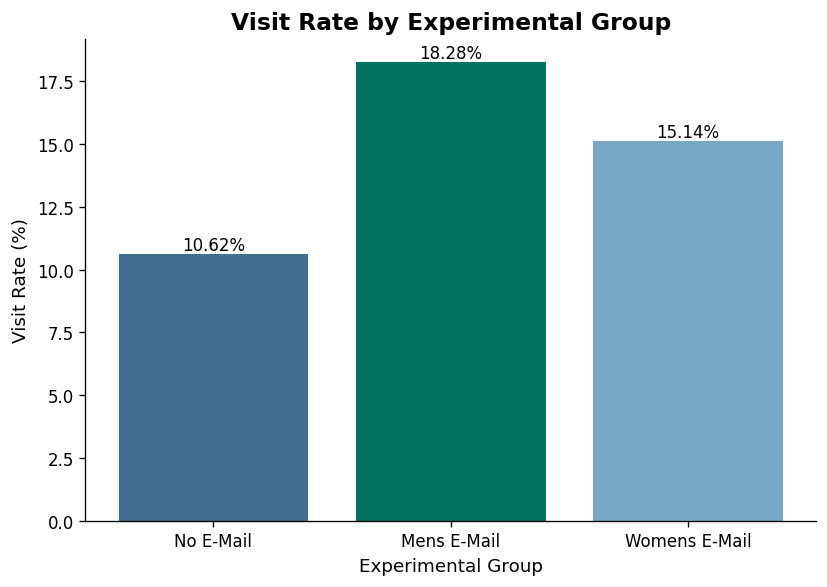

In [154]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    treatment_outcomes.index,
    treatment_outcomes["visit_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Visit Rate by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Visit Rate (%)")

for bar, value in zip(bars,treatment_outcomes["visit_rate"],):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

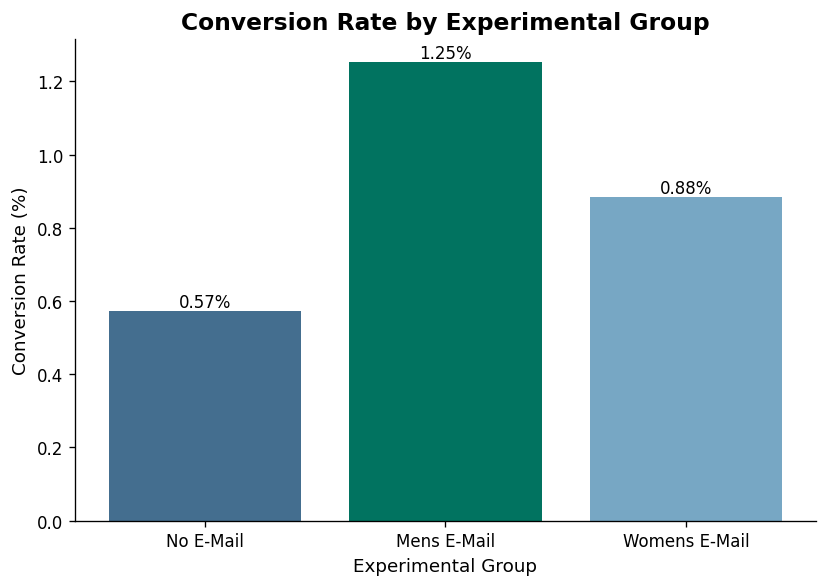

In [155]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    treatment_outcomes.index,
    treatment_outcomes["conversion_rate"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Conversion Rate by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Conversion Rate (%)")

for bar, value in zip(bars,treatment_outcomes["conversion_rate"],):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

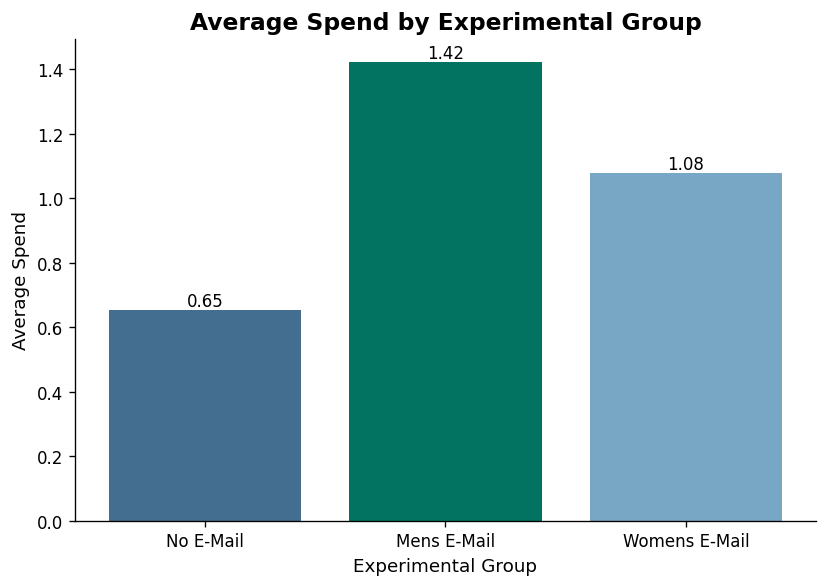

In [156]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    treatment_outcomes.index,
    treatment_outcomes["average_spend"],
    color=[
        COLORS["rainy_lake"],
        COLORS["pacific_green"],
        COLORS["serene_sea"],
    ],
)

ax.set_title("Average Spend by Experimental Group")
ax.set_xlabel("Experimental Group")
ax.set_ylabel("Average Spend")

for bar, value in zip(bars,treatment_outcomes["average_spend"],):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [157]:
control = treatment_outcomes.loc[
    "No E-Mail"
]

raw_effects = pd.DataFrame({
    "Mens E-Mail": [
        treatment_outcomes.loc["Mens E-Mail","visit_rate",] - control["visit_rate"],

        treatment_outcomes.loc["Mens E-Mail","conversion_rate",] - control["conversion_rate"],

        treatment_outcomes.loc["Mens E-Mail","average_spend",] - control["average_spend"],
    ],

    "Womens E-Mail": [
        treatment_outcomes.loc["Womens E-Mail","visit_rate",] - control["visit_rate"],

        treatment_outcomes.loc["Womens E-Mail","conversion_rate",] - control["conversion_rate"],

        treatment_outcomes.loc["Womens E-Mail","average_spend",] - control["average_spend"],
    ],
}, index=[
    "Visit rate difference (pp)",
    "Conversion rate difference (pp)",
    "Average spend difference",
])

display(raw_effects.round(3))

,Mens E-Mail,Womens E-Mail
Visit rate difference (pp),7.6590,4.5230
Conversion rate difference (pp),0.6810,0.3110
Average spend difference,0.7700,0.4240


### Outcomes Across Experimental Groups

The observed outcomes differ clearly across the three experimental groups.

| Experimental group | Visit rate | Conversion rate | Average spend |
|---|---:|---:|---:|
| No E-Mail | 10.62% | 0.57% | 0.65 |
| Mens E-Mail | 18.28% | 1.25% | 1.42 |
| Womens E-Mail | 15.14% | 0.88% | 1.08 |

Compared with the `No E-Mail` control group:

- **Mens E-Mail** increases the observed visit rate by **7.66 percentage points**, conversion rate by **0.68 percentage points**, and average spend by **0.77**.
- **Womens E-Mail** increases the observed visit rate by **4.52 percentage points**, conversion rate by **0.31 percentage points**, and average spend by **0.42**.

Both email campaigns show better average outcomes than sending no email, but the observed effect is consistently larger for the Mens campaign.

These are population-level, unadjusted treatment differences. Given the randomized design and the balance checks performed earlier, they provide initial evidence of an average campaign effect. The next step is to test whether these differences are statistically supported and, more importantly for uplift modeling, whether the treatment effect varies across different types of customers.

### Does Treatment Response Vary Across Customer Characteristics?

Population-level treatment effects may hide differences between customer subgroups.

To explore possible treatment heterogeneity, raw visit-rate differences are compared between each email campaign and the corresponding `No E-Mail` customers across:

- recency;
- historical spending;
- new/existing customer status;
- prior product affinity.

These comparisons are exploratory and are used to identify patterns worth testing formally in the next stage.

In [158]:
def subgroup_uplift(data, group_column, treatment):
    rates = (
        data[data["segment"].isin([treatment, "No E-Mail"])]
        .groupby([group_column, "segment"])["visit"]
        .mean()
        .unstack()
    )

    rates["raw_uplift"] = (rates[treatment] - rates["No E-Mail"]) * 100

    return rates

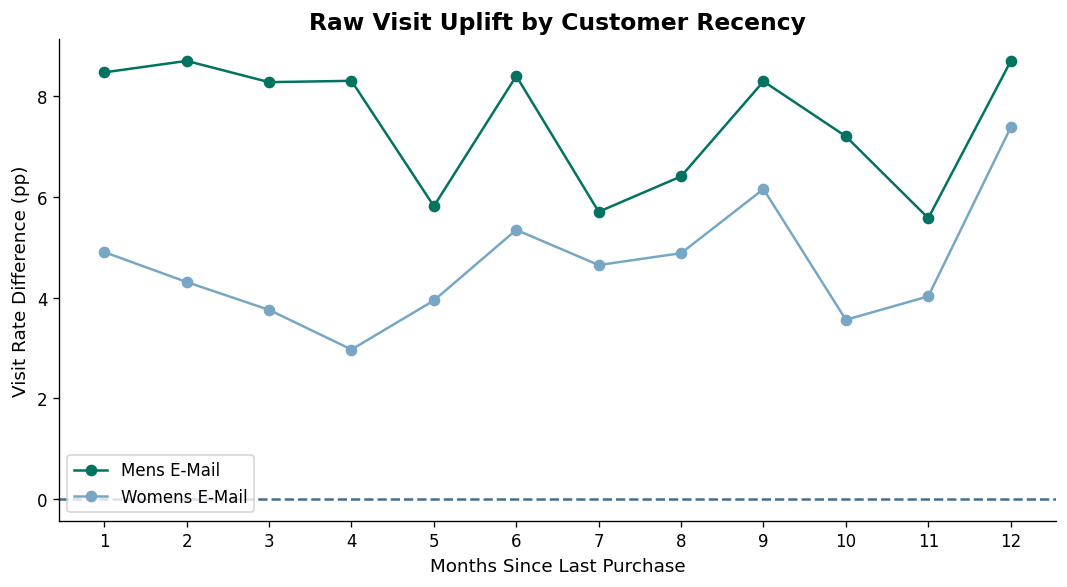

In [159]:
mens_recency = subgroup_uplift(df,"recency","Mens E-Mail",)

womens_recency = subgroup_uplift(df,"recency","Womens E-Mail",)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    mens_recency.index,
    mens_recency["raw_uplift"],
    marker="o",
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.plot(
    womens_recency.index,
    womens_recency["raw_uplift"],
    marker="o",
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.axhline(0,color=COLORS["rainy_lake"],linestyle="--",)

ax.set_title("Raw Visit Uplift by Customer Recency")
ax.set_xlabel("Months Since Last Purchase")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(range(1, 13))
ax.legend()

plt.tight_layout()
plt.show()

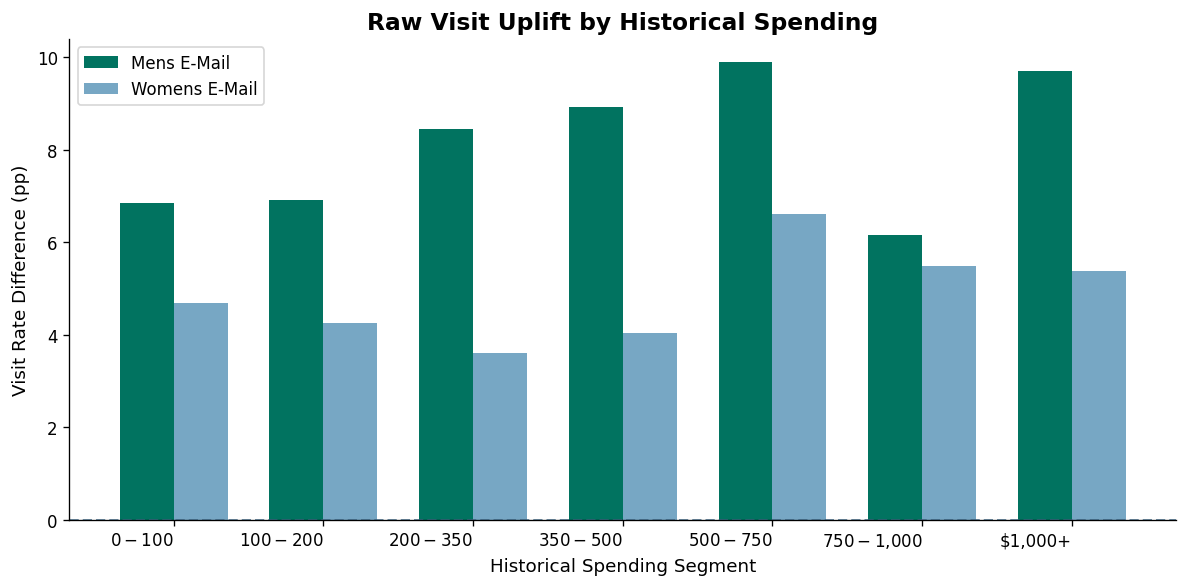

In [160]:
history_order = [
    "$0 - $100",
    "$100 - $200",
    "$200 - $350",
    "$350 - $500",
    "$500 - $750",
    "$750 - $1,000",
    "$1,000+",
]

mens_history = subgroup_uplift(df,"history_segment", "Mens E-Mail",).reindex(history_order)

womens_history = subgroup_uplift(df,"history_segment","Womens E-Mail",).reindex(history_order)

x = np.arange(len(history_order))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    mens_history["raw_uplift"],
    width,
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.bar(
    x + width / 2,
    womens_history["raw_uplift"],
    width,
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.axhline(0,color=COLORS["rainy_lake"],linestyle="--",)

ax.set_title("Raw Visit Uplift by Historical Spending")
ax.set_xlabel("Historical Spending Segment")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(x)
ax.set_xticklabels(history_order,ha="right",)
ax.legend()
plt.tight_layout()
plt.show()

In [161]:
mens_newbie = subgroup_uplift(df,"newbie","Mens E-Mail",)

womens_newbie = subgroup_uplift(df,"newbie","Womens E-Mail",)

newbie_uplift = pd.DataFrame({"Mens E-Mail": mens_newbie["raw_uplift"],"Womens E-Mail": womens_newbie["raw_uplift"],})

newbie_uplift.index = ["Existing","New",]

display(newbie_uplift.round(2))

,Mens E-Mail,Womens E-Mail
Existing,7.7800,4.0100
New,7.5300,5.0400


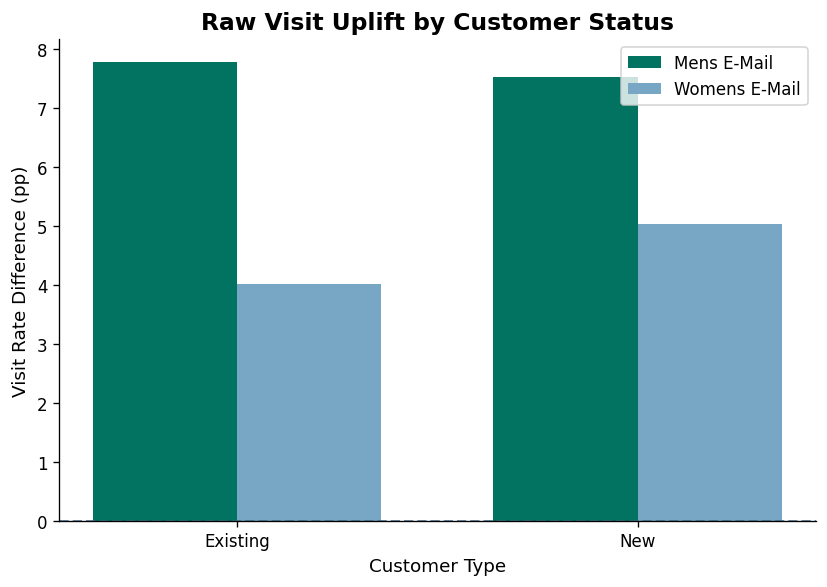

In [162]:
x = np.arange(2)
width = 0.36

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    x - width / 2,
    newbie_uplift["Mens E-Mail"],
    width,
    color=COLORS["pacific_green"],
    label="Mens E-Mail",
)

ax.bar(
    x + width / 2,
    newbie_uplift["Womens E-Mail"],
    width,
    color=COLORS["serene_sea"],
    label="Womens E-Mail",
)

ax.axhline(0,color=COLORS["rainy_lake"],linestyle="--",)

ax.set_title("Raw Visit Uplift by Customer Status")
ax.set_xlabel("Customer Type")
ax.set_ylabel("Visit Rate Difference (pp)")
ax.set_xticks(x)
ax.set_xticklabels(["Existing","New",])
ax.legend()
plt.tight_layout()
plt.show()

In [163]:
mens_affinity = subgroup_uplift(df,"mens","Mens E-Mail",)

mens_affinity.index = ["No Prior Mens Purchase","Prior Mens Purchase",]

display(mens_affinity.round(3))

segment,Mens E-Mail,No E-Mail,raw_uplift
No Prior Mens Purchase,0.1660,0.0960,7.0580
Prior Mens Purchase,0.1960,0.1150,8.1570


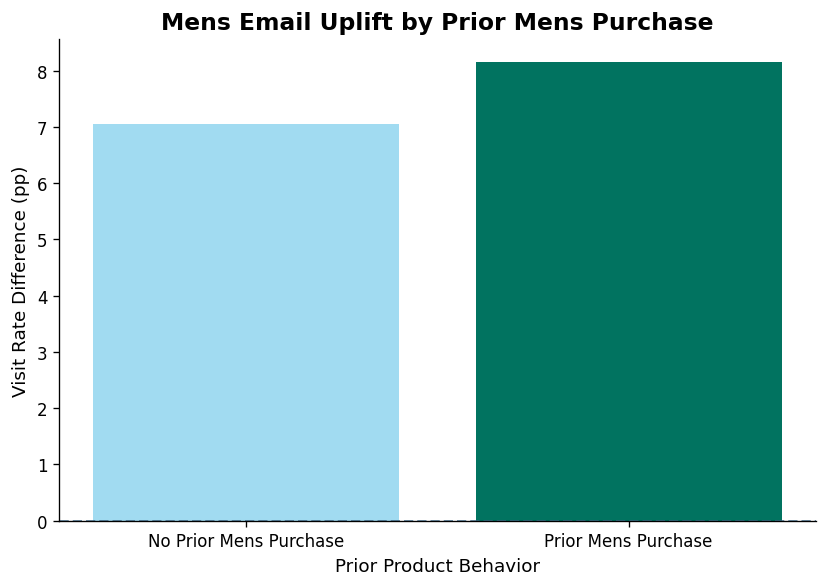

In [164]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    mens_affinity.index,
    mens_affinity["raw_uplift"],
    color=[
        COLORS["sora_blue"],
        COLORS["pacific_green"],
    ],
)

ax.axhline(0,color=COLORS["rainy_lake"],linestyle="--",)

ax.set_title("Mens Email Uplift by Prior Mens Purchase")
ax.set_xlabel("Prior Product Behavior")
ax.set_ylabel("Visit Rate Difference (pp)")

plt.tight_layout()
plt.show()

segment,No E-Mail,Womens E-Mail,raw_uplift
No Prior Womens Purchase,0.1000,0.1110,1.1080
Prior Womens Purchase,0.1110,0.1850,7.3110


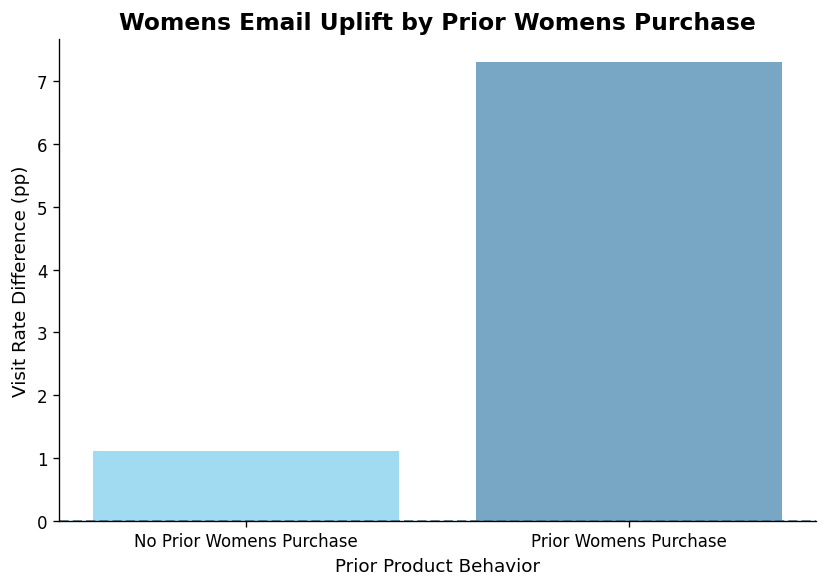

In [165]:
womens_affinity = subgroup_uplift(df,"womens","Womens E-Mail",)

womens_affinity.index = ["No Prior Womens Purchase","Prior Womens Purchase",]

display(womens_affinity.round(3))

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    womens_affinity.index,
    womens_affinity["raw_uplift"],
    color=[
        COLORS["sora_blue"],
        COLORS["serene_sea"],
    ],
)

ax.axhline(0,color=COLORS["rainy_lake"],linestyle="--",)

ax.set_title("Womens Email Uplift by Prior Womens Purchase")
ax.set_xlabel("Prior Product Behavior")
ax.set_ylabel("Visit Rate Difference (pp)")

plt.tight_layout()
plt.show()

The raw visit uplift is not the same across all customer groups.

- **Recency:** Both campaigns have positive uplift across all recency levels, but the values move up and down without a clear trend. 

- **Historical spending:** Uplift changes across spending groups for both campaigns. However, the pattern is not steadily increasing or decreasing with customer spending, so historical value may matter, but the relationship is not simple.

- **Customer status:** Mens E-Mail performs similarly for existing and new customers (**7.78 pp vs 7.53 pp**). Womens E-Mail shows a slightly larger difference, with new customers responding more strongly than existing customers (**5.04 pp vs 4.01 pp**).

- **Prior product affinity:** This is the clearest difference. Mens E-Mail has somewhat higher uplift among customers with prior Mens purchases (**8.16 pp vs 7.06 pp**). For Womens E-Mail, the difference is much larger: uplift is **7.31 pp** for customers with prior Womens purchases, compared with only **1.11 pp** for customers without them.

The strongest pattern is therefore related to previous purchases in the same product category as the email campaign.

### What Patterns Suggest Treatment Heterogeneity?

**Prior product affinity** is the strongest candidate. Customers who previously purchased from the promoted category appear to respond more strongly, especially to Womens E-Mail.

**Historical spending** also shows differences in uplift across customer groups, although there is no clear linear pattern.

**Customer status** shows only a small difference, mainly for Womens E-Mail.

**Recency** varies across months but does not show a clear direction.

## Candidate Hypotheses

Based on the EDA, three patterns are worth testing more formally.

### H1 — Prior Product Affinity

**Hypothesis:** The effect of an email campaign differs depending on whether the customer previously purchased from the promoted product category.

This is the strongest candidate because the largest subgroup difference appears between customers with and without matching product history.

### H2 — Historical Spending

**Hypothesis:** The effect of an email campaign differs across customers with different levels of historical spending.

The EDA shows variation across spending groups, but statistical testing is needed to determine whether these differences are meaningful or simply sampling variation.

### H3 — Customer Status

**Hypothesis:** The effect of Womens E-Mail differs between new and existing customers.

The observed difference is smaller than for product affinity, so this is treated as a secondary hypothesis.